# BNS GRB Classes and Formation Channels

**Hypothesis:** The Gottlieb et al. (2023) BNS GRB sub-types, Short cbGRB ($q < 1.2$ or $M_{\rm tot} < M_{\rm crit}$) and Long cbGRB ($M_{\rm tot} \geq M_{\rm crit}$ and $q \geq 1.2$), trace back to physically distinct isolated binary evolution formation channels (Double-core CE vs Classic CE), following the framework of Broekgaarden et al. ([2021, Paper I](https://arxiv.org/abs/2103.02608); [2022, Paper II](https://arxiv.org/abs/2112.05763)).

**Physical motivation:**
- **Double-core CE** (Channel IV): Both stars on the giant branch with similar initial masses ($q_i \sim 0.9$-$1.0$), stripped simultaneously, producing nearly equal-mass NS pairs with $q_{\rm final} \approx 1.0$, placing them in Short GRB territory.
- **Classic CE** (Channel I): Primary stripped by stable RLOF then CCSN produces NS$_1$; secondary undergoes CE with NS then USSN produces NS$_2$. Different SN mechanisms can produce $q_{\rm final} \geq 1.2$, placing them in Long cbGRB territory.
- For GW-detectable BNS, Broekgaarden et al. (2021, Section 3.5.1) predict ~60-70% form via the Double-core CE channel in their fiducial model, citing Vigna-Gomez et al. (2018). This fraction refers to the detection-weighted population; the intrinsic fraction may differ. BHNS systems are dominated by the Classic channel.

**Scenario note:** The three sub-populations (Short Type I, Short Type II, Long) are working labels from a combined framework drawing on both the hybrid and all-BH scenarios of Gottlieb et al. (2023). See `GRB_BNS.ipynb` for the full scenario description.

**Data:** COMPAS Model A fiducial BNS: [Zenodo 5189849](https://zenodo.org/records/5189849)

## 1. Imports & Data Loading

In [23]:
import h5py as h5
import numpy as np
import matplotlib.pyplot as plt
import sys
from scipy.interpolate import interp1d

path = '/Users/josephrodriguez/research visualization/Data/COMPASCompactOutput_BNS_A.h5'

with h5.File(path, 'r') as f:
    fDCO = f['doubleCompactObjects']

    # ── Columns from GRB_BNS.ipynb ───────────────────────────────────────────
    mass1              = fDCO['M1'][...].squeeze()
    mass2              = fDCO['M2'][...].squeeze()
    weights            = fDCO['weight'][...].squeeze()
    metallicitySystems = fDCO['Metallicity1'][...].squeeze()
    mergesInHubbleTime = fDCO['mergesInHubbleTimeFlag'][...].squeeze()
    tc                 = fDCO['tc'][...].squeeze()
    tform              = fDCO['tform'][...].squeeze()
    m1zams             = fDCO['M1ZAMS'][...].squeeze()
    m2zams             = fDCO['M2ZAMS'][...].squeeze()

    # ── NEW columns for formation channel analysis ───────────────────────────
    dblCEflag          = fDCO['doubleCommonEnvelopeFlag'][...].squeeze()
    ecsn1              = fDCO['ECSNPrimary'][...].squeeze()
    ecsn2              = fDCO['ECSNSecondary'][...].squeeze()
    ussn1              = fDCO['USSNPrimary'][...].squeeze()
    ussn2              = fDCO['USSNSecondary'][...].squeeze()
    mtCase1            = fDCO['PrimaryMTCase'][...].squeeze()
    mtCase2            = fDCO['SecondaryMTCase'][...].squeeze()
    stype1             = fDCO['stellarType1'][...].squeeze()
    stype2             = fDCO['stellarType2'][...].squeeze()
    rl12_preCE         = fDCO['RL1to2PreCEE'][...].squeeze()
    rl12_postCE        = fDCO['RL1to2PostCEE'][...].squeeze()
    rl21_preCE         = fDCO['RL2to1PreCEE'][...].squeeze()
    rl21_postCE        = fDCO['RL2to1PostCEE'][...].squeeze()
    sep_preCE          = fDCO['SemiMajorAxisPreCEE'][...].squeeze()
    sep_postCE         = fDCO['SemiMajorAxisPostCEE'][...].squeeze()

    # ── Inspect formationChannels group ──────────────────────────────────────
    print('=== HDF5 top-level groups ===')
    print(list(f.keys()))
    print()

    fc = f['formationChannels']
    print('=== formationChannels keys ===')
    print(list(fc.keys()))
    print()
    for k in fc.keys():
        ds = fc[k]
        print(f"  {k}: shape={ds.shape}, dtype={ds.dtype}")
        try:
            print(f"    first 3: {ds[:3]}")
        except Exception as e:
            print(f"    (could not preview: {e})")

print(f"\nTotal BNS systems: {len(mass1):,}")

=== HDF5 top-level groups ===
['RLOF', 'commonEnvelopes', 'doubleCompactObjects', 'formationChannels', 'supernovae', 'systems', 'weights_detected', 'weights_detectedPerRedshift', 'weights_intrinsic', 'weights_intrinsicPerRedshift']

=== formationChannels keys ===
['CEE', 'CEE_failed', 'CEE_failed_instigator', 'CEE_instigator', 'CEE_wet', 'CEE_wet_instigator', 'SN_primary_type_1', 'SN_primary_type_2', 'SN_primary_type_3', 'SN_secondary_type_1', 'SN_secondary_type_2', 'SN_secondary_type_3', 'binary_disbound', 'eventCounter', 'm_randomSeed', 'merged_in_Hubble_time', 'mt_primary_ep1', 'mt_primary_ep1_K1', 'mt_primary_ep1_K2', 'mt_primary_ep2', 'mt_primary_ep2_K1', 'mt_primary_ep2_K2', 'mt_primary_ep3', 'mt_primary_ep3_K1', 'mt_primary_ep3_K2', 'mt_secondary_ep1', 'mt_secondary_ep1_K1', 'mt_secondary_ep1_K2', 'mt_secondary_ep2', 'mt_secondary_ep2_K1', 'mt_secondary_ep2_K2', 'mt_secondary_ep3', 'mt_secondary_ep3_K1', 'mt_secondary_ep3_K2', 'stellar_type_K1', 'stellar_type_K2']

  CEE: shape=

## 2. Gottlieb GRB Classification

Replicated from `GRB_BNS.ipynb`: Gottlieb et al. (2023) mass and mass-ratio thresholds with $M_{\rm crit} = 2.8\,M_\odot$, $q_{\rm thresh} = 1.2$. The three sub-populations (Short Type I, Short Type II, Long) are working labels from a combined framework; see `GRB_BNS.ipynb` for the full hybrid vs all-BH scenario description.

In [24]:
mask_merging = (mergesInHubbleTime == 1)

M_tot = mass1[mask_merging] + mass2[mask_merging]
q     = np.maximum(mass1[mask_merging], mass2[mask_merging]) / \
        np.minimum(mass1[mask_merging], mass2[mask_merging])

M_crit = 2.8

short_typeI  = (M_tot < M_crit)
short_typeII = (M_tot >= M_crit) & (q < 1.2)
short_cbGRB  = short_typeI | short_typeII
long_cbGRB   = (M_tot >= M_crit) & (q >= 1.2)

# Merging-subset arrays for downstream analysis
w_m      = weights[mask_merging]
Z_m      = metallicitySystems[mask_merging]
delay_m  = (tform + tc)[mask_merging]
m1z_m    = m1zams[mask_merging]
m2z_m    = m2zams[mask_merging]
dblCE_m  = dblCEflag[mask_merging]
ecsn1_m  = ecsn1[mask_merging]
ecsn2_m  = ecsn2[mask_merging]
ussn1_m  = ussn1[mask_merging]
ussn2_m  = ussn2[mask_merging]
mtC1_m   = mtCase1[mask_merging]
mtC2_m   = mtCase2[mask_merging]
sep_pre  = sep_preCE[mask_merging]
sep_post = sep_postCE[mask_merging]

n_merging = mask_merging.sum()
print(f"Merging BNS:         {n_merging:,}")
print(f"Short Type I  (HMNS):    {short_typeI.sum():,}  ({100*short_typeI.mean():.1f}%)")
print(f"Short Type II (BH+disk): {short_typeII.sum():,}  ({100*short_typeII.mean():.1f}%)")
print(f"Long cbGRB:              {long_cbGRB.sum():,}  ({100*long_cbGRB.mean():.1f}%)")

Merging BNS:         233,137
Short Type I  (HMNS):    160,646  (68.9%)
Short Type II (BH+disk): 29,209  (12.5%)
Long cbGRB:              43,282  (18.6%)


## 3. Quick Proxy Test: $q_{\rm ZAMS}$ by GRB Class

Before touching the formation channel data, test the hypothesis using ZAMS mass ratios already available. The Double-core CE channel requires $q_i \sim 0.9$-$1.0$ (Broekgaarden et al. [2021](https://arxiv.org/abs/2103.02608), Section 3.1.4; [2022](https://arxiv.org/abs/2112.05763)). If Long cbGRBs come from systematically more unequal initial mass ratios, the hypothesis has immediate support.

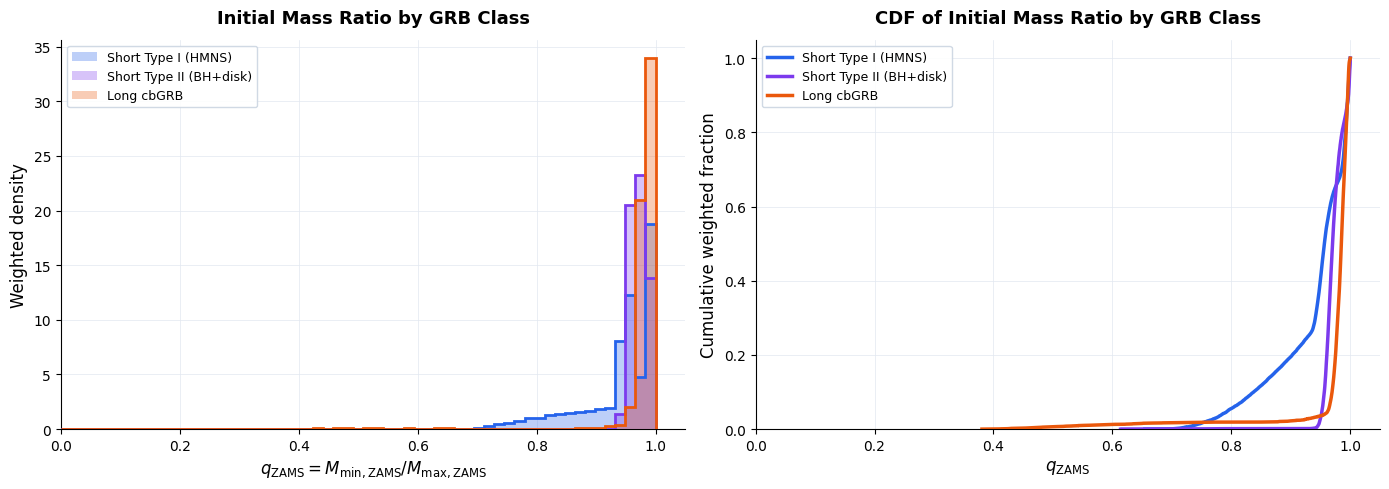

Short I       weighted mean q_ZAMS = 0.940  median = 0.956  frac(q_ZAMS > 0.85) = 0.883
Short II      weighted mean q_ZAMS = 0.972  median = 0.970  frac(q_ZAMS > 0.85) = 0.999
Long          weighted mean q_ZAMS = 0.975  median = 0.985  frac(q_ZAMS > 0.85) = 0.981


In [40]:
q_zams = np.minimum(m1z_m, m2z_m) / np.maximum(m1z_m, m2z_m)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax in axes:
    ax.set_axisbelow(True)
    ax.grid(True, color='#E2E8F0', linewidth=0.5, zorder=0)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# ── Left: weighted histograms ────────────────────────────────────────────────
ax = axes[0]
bins = np.linspace(0.0, 1.0, 60)
for label, mask, color in [
    ('Short Type I (HMNS)',    short_typeI,  '#2563EB'),
    ('Short Type II (BH+disk)', short_typeII, '#7C3AED'),
    ('Long cbGRB',             long_cbGRB,   '#EA580C'),
]:
    ax.hist(q_zams[mask], bins=bins, weights=w_m[mask],
            density=True, histtype='stepfilled', lw=1.5, color=color,
            label=label, alpha=0.3, zorder=3)
    ax.hist(q_zams[mask], bins=bins, weights=w_m[mask],
            density=True, histtype='step', lw=2, color=color, zorder=4)

ax.set_xlabel(r'$q_{\rm ZAMS} = M_{\rm min,ZAMS} / M_{\rm max,ZAMS}$', fontsize=12)
ax.set_ylabel('Weighted density', fontsize=12)
ax.set_title(r'Initial Mass Ratio by GRB Class', fontsize=13, fontweight='bold', pad=12)
ax.legend(fontsize=9, framealpha=0.9, edgecolor='#CBD5E1')
ax.set_xlim(0, 1.05)

# ── Right: weighted CDFs ─────────────────────────────────────────────────────
ax = axes[1]
for label, mask, color in [
    ('Short Type I (HMNS)',    short_typeI,  '#2563EB'),
    ('Short Type II (BH+disk)', short_typeII, '#7C3AED'),
    ('Long cbGRB',             long_cbGRB,   '#EA580C'),
]:
    vals = q_zams[mask]
    wts  = w_m[mask]
    order = np.argsort(vals)
    cdf   = np.cumsum(wts[order])
    cdf  /= cdf[-1]
    ax.plot(vals[order], cdf, lw=2.5, color=color, label=label, zorder=3)

ax.set_xlabel(r'$q_{\rm ZAMS}$', fontsize=12)
ax.set_ylabel('Cumulative weighted fraction', fontsize=12)
ax.set_title(r'CDF of Initial Mass Ratio by GRB Class', fontsize=13, fontweight='bold', pad=12)
ax.legend(fontsize=9, loc='upper left', framealpha=0.9, edgecolor='#CBD5E1')
ax.set_xlim(0, 1.05)
ax.set_ylim(0, 1.05)

plt.tight_layout()
plt.savefig('/Users/josephrodriguez/research visualization/Plots/bns_qzams_by_grb_class.png',
            dpi=200, bbox_inches='tight')
plt.show()

# ── Summary statistics ───────────────────────────────────────────────────────
for label, mask in [('Short I', short_typeI), ('Short II', short_typeII), ('Long', long_cbGRB)]:
    vals = q_zams[mask]
    wts  = w_m[mask]
    wmean = np.average(vals, weights=wts)
    wmed  = vals[np.argsort(vals)][np.searchsorted(np.cumsum(wts[np.argsort(vals)]) / wts[np.argsort(vals)].sum(), 0.5)]
    frac_high = np.sum(wts[vals > 0.85]) / np.sum(wts)
    print(f"{label:12s}  weighted mean q_ZAMS = {wmean:.3f}  "
          f"median = {wmed:.3f}  frac(q_ZAMS > 0.85) = {frac_high:.3f}")

## 4. Formation Channel Classification

Classify merging BNS into formation channels following Broekgaarden et al. ([2021](https://arxiv.org/abs/2103.02608); [2022](https://arxiv.org/abs/2112.05763)) Section 3.1.

- **Channel IV (Double-core CE):** `doubleCommonEnvelopeFlag == 1`, meaning both stars had a core-envelope structure during the first CE.
- **Channel I (Classic):** Not double CE; experienced at least one CE event (`sep_preCE > 0`) and had a prior or subsequent stable RLOF.
- **Channel II (Only stable MT):** No CE event at all (CE separation columns are default/zero).
- **Channel III (Single-core CE first):** First MT is an unstable CE (not double-core); the secondary is still a MS star.
- **Channel V (Other):** Everything else.

The `doubleCommonEnvelopeFlag` directly identifies Channel IV. For the remaining channels, we use the CE separation columns and mass-transfer case flags.

**Note:** The Channel III identification using `PrimaryMTCase == 0` assumes this value means "no prior stable mass transfer occurred." This interpretation should be verified against COMPAS column definitions. The `formationChannels` HDF5 group (inspected in Section 1) may provide more reliable event-sequence labels.

In [26]:
had_CE = (sep_pre > 0)

ch_IV    = (dblCE_m == 1)
ch_II    = ~had_CE & ~ch_IV
ch_III   = had_CE & ~ch_IV & (mtC1_m == 0)
ch_I     = had_CE & ~ch_IV & ~ch_III
ch_other = ~(ch_I | ch_II | ch_III | ch_IV)

channel_masks = {
    'I  Classic CE':     ch_I,
    'II  Stable MT only': ch_II,
    'III Single-core CE': ch_III,
    'IV  Double-core CE': ch_IV,
    'V   Other':          ch_other,
}

print(f"{'Channel':<22s} {'Count':>8s} {'Weighted %':>12s}")
print('-' * 44)
total_w = w_m.sum()
for name, mask in channel_masks.items():
    n = mask.sum()
    wpct = 100 * w_m[mask].sum() / total_w
    print(f"{name:<22s} {n:>8,d} {wpct:>11.1f}%")
print(f"{'TOTAL':<22s} {n_merging:>8,d} {100.0:>11.1f}%")

Channel                   Count   Weighted %
--------------------------------------------
I  Classic CE            36,019        25.3%
II  Stable MT only            0         0.0%
III Single-core CE           37         0.1%
IV  Double-core CE      197,081        74.6%
V   Other                     0         0.0%
TOTAL                   233,137       100.0%


## 5. Cross-Tabulation: GRB Class × Formation Channel

The core hypothesis test. For each GRB class, compute the STROOPWAFEL-weighted fraction from each formation channel.

**Expected if hypothesis holds:**
- Long cbGRB: dominated by Classic CE (Channel I)
- Short Type II: dominated by Double-core CE (Channel IV)
- Short Type I: mixed (lower $M_{\rm tot}$ from both channels)

GRB Class                      I  Classic CEII  Stable MT onlyIII Single-core CEIV  Double-core CE         V   Other
--------------------------------------------------------------------------------------------------------------------
Short Type I (HMNS)                    39.1%              0.0%              0.1%             60.8%              0.0%
Short Type II (BH+disk)                 0.2%              0.0%              0.1%             99.8%              0.0%
Long cbGRB                              7.2%              0.0%              0.2%             92.6%              0.0%


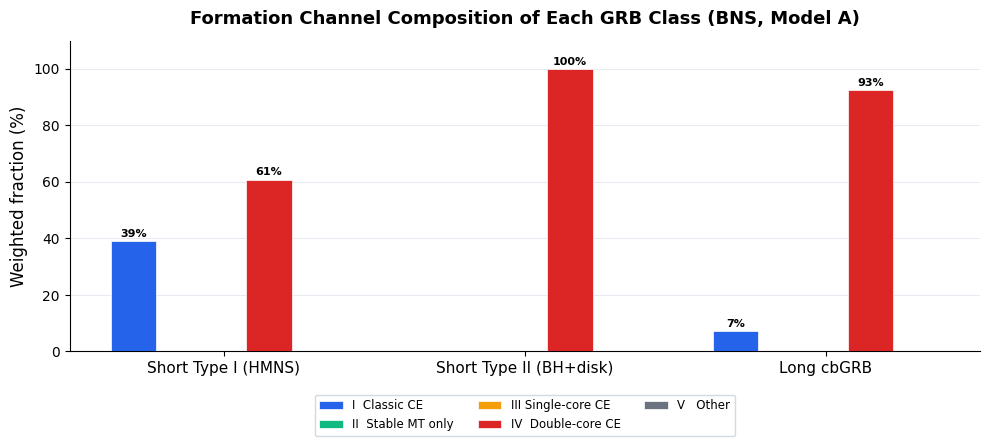

In [39]:
grb_classes = {
    'Short Type I (HMNS)':    short_typeI,
    'Short Type II (BH+disk)': short_typeII,
    'Long cbGRB':              long_cbGRB,
}

# ── Build table ──────────────────────────────────────────────────────────────
ch_names  = list(channel_masks.keys())
grb_names = list(grb_classes.keys())

table = np.zeros((len(grb_names), len(ch_names)))
for i, (gname, gmask) in enumerate(grb_classes.items()):
    w_grb = w_m[gmask].sum()
    for j, (cname, cmask) in enumerate(channel_masks.items()):
        table[i, j] = w_m[gmask & cmask].sum() / w_grb * 100

# ── Print ─────────────────────────────────────────────────────────────────────
header = f"{'GRB Class':<26s}" + ''.join(f"{c:>18s}" for c in ch_names)
print(header)
print('-' * len(header))
for i, gname in enumerate(grb_names):
    row = f"{gname:<26s}" + ''.join(f"{table[i,j]:>17.1f}%" for j in range(len(ch_names)))
    print(row)

# ── Bar chart ─────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

ax.set_axisbelow(True)
ax.yaxis.grid(True, color='#E2E8F0', linewidth=0.6, zorder=0)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

x = np.arange(len(grb_names))
width = 0.15
ch_colors = ['#2563EB', '#10B981', '#F59E0B', '#DC2626', '#6B7280']

for j, (cname, color) in enumerate(zip(ch_names, ch_colors)):
    offset = (j - len(ch_names)/2 + 0.5) * width
    bars = ax.bar(x + offset, table[:, j], width, label=cname, color=color,
                  edgecolor='white', lw=0.5, zorder=3)
    for bar, val in zip(bars, table[:, j]):
        if val > 2:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.8,
                    f'{val:.0f}%', ha='center', va='bottom', fontsize=8, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(grb_names, fontsize=11, fontweight='medium')
ax.set_ylabel('Weighted fraction (%)', fontsize=12)
ax.set_title('Formation Channel Composition of Each GRB Class (BNS, Model A)',
             fontsize=13, fontweight='bold', pad=12)
ax.legend(fontsize=8.5, ncol=3, loc='upper center', bbox_to_anchor=(0.5, -0.12),
          framealpha=0.9, edgecolor='#CBD5E1')
ax.set_ylim(0, 110)

plt.tight_layout(rect=[0, 0.07, 1, 1])
plt.savefig('/Users/josephrodriguez/research visualization/Plots/bns_grb_vs_channel_bar.png',
            dpi=200, bbox_inches='tight')
plt.show()

## 6. Mass-Plane Visualization by Formation Channel

$M_1$ vs $M_2$ scatter colored by formation channel, with Gottlieb classification boundaries overlaid ($M_{\rm crit} = 2.8\,M_\odot$ and $q = 1.2$). Masses sorted so $M_1 \geq M_2$.

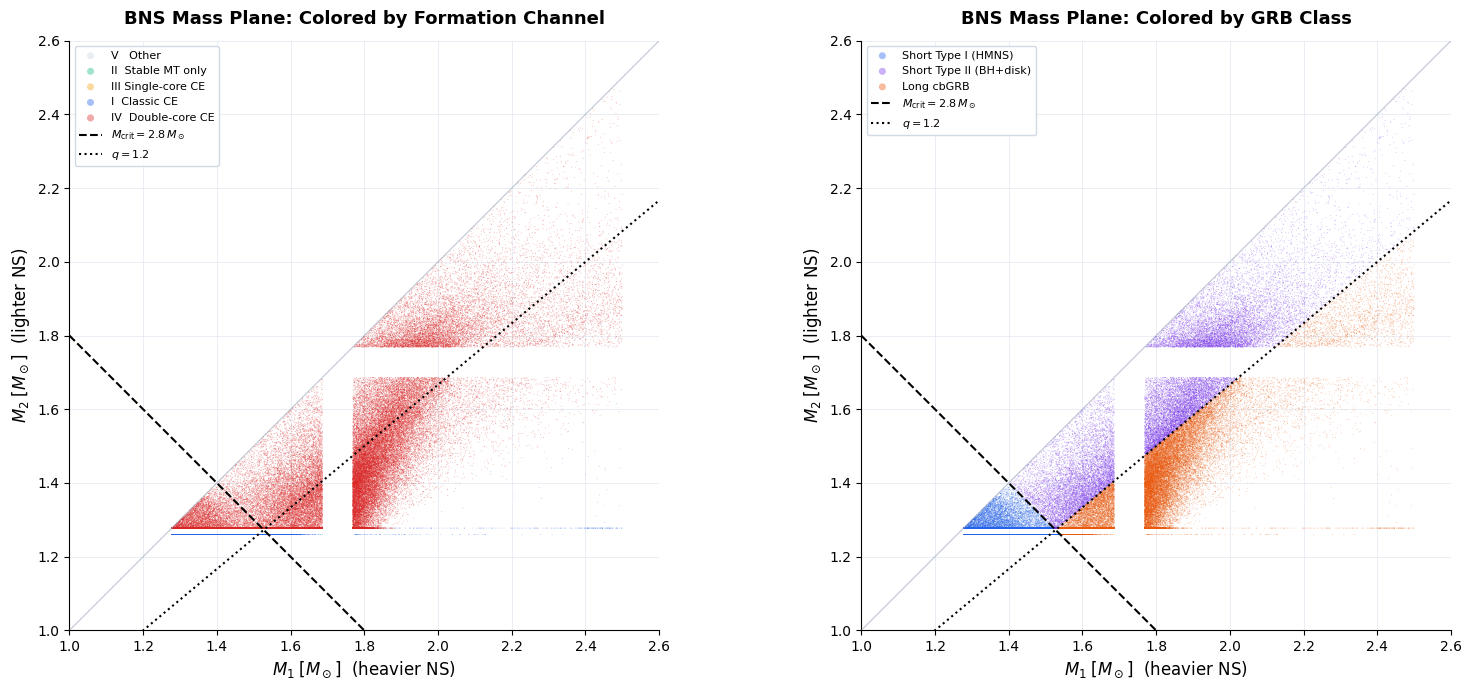

In [38]:
m1 = np.maximum(mass1[mask_merging], mass2[mask_merging])
m2 = np.minimum(mass1[mask_merging], mass2[mask_merging])

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# ── Left panel: colored by formation channel ────────────────────────────────
ax = axes[0]
ch_plot_order = ['V   Other', 'II  Stable MT only', 'III Single-core CE', 'I  Classic CE', 'IV  Double-core CE']
ch_colors_map = {
    'I  Classic CE':      '#2563EB',
    'II  Stable MT only': '#10B981',
    'III Single-core CE': '#F59E0B',
    'IV  Double-core CE': '#DC2626',
    'V   Other':          '#CBD5E1',
}

ax.set_axisbelow(True)
ax.grid(True, color='#E2E8F0', linewidth=0.5, zorder=0)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

for cname in ch_plot_order:
    cmask = channel_masks[cname]
    ax.scatter(m1[cmask], m2[cmask], s=0.4, alpha=0.4, color=ch_colors_map[cname],
              label=cname, rasterized=True, edgecolors='none', zorder=3)

ms = np.linspace(1.0, 2.6, 200)
ax.plot(ms, M_crit - ms, 'k--', lw=1.5, zorder=5, label=rf'$M_{{\rm crit}} = {M_crit}\,M_\odot$')
ax.plot(ms, ms / 1.2, 'k:', lw=1.5, zorder=5, label=r'$q = 1.2$')
ax.plot(ms, ms, '-', color='#94A3B8', lw=0.8, alpha=0.6, zorder=4)

ax.set_xlabel(r'$M_1\;[M_\odot]$  (heavier NS)', fontsize=12)
ax.set_ylabel(r'$M_2\;[M_\odot]$  (lighter NS)', fontsize=12)
ax.set_title('BNS Mass Plane: Colored by Formation Channel', fontsize=13, fontweight='bold', pad=12)
ax.legend(fontsize=8, markerscale=8, loc='upper left', framealpha=0.9, edgecolor='#CBD5E1')
ax.set_xlim(1.0, 2.6)
ax.set_ylim(1.0, 2.6)
ax.set_aspect('equal')

# ── Right panel: colored by GRB class ───────────────────────────────────────
ax = axes[1]

ax.set_axisbelow(True)
ax.grid(True, color='#E2E8F0', linewidth=0.5, zorder=0)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

for label, mask, color in [
    ('Short Type I (HMNS)',    short_typeI,  '#2563EB'),
    ('Short Type II (BH+disk)', short_typeII, '#7C3AED'),
    ('Long cbGRB',             long_cbGRB,   '#EA580C'),
]:
    ax.scatter(m1[mask], m2[mask], s=0.4, alpha=0.4, color=color,
              label=label, rasterized=True, edgecolors='none', zorder=3)

ax.plot(ms, M_crit - ms, 'k--', lw=1.5, zorder=5, label=rf'$M_{{\rm crit}} = {M_crit}\,M_\odot$')
ax.plot(ms, ms / 1.2, 'k:', lw=1.5, zorder=5, label=r'$q = 1.2$')
ax.plot(ms, ms, '-', color='#94A3B8', lw=0.8, alpha=0.6, zorder=4)

ax.set_xlabel(r'$M_1\;[M_\odot]$  (heavier NS)', fontsize=12)
ax.set_ylabel(r'$M_2\;[M_\odot]$  (lighter NS)', fontsize=12)
ax.set_title('BNS Mass Plane: Colored by GRB Class', fontsize=13, fontweight='bold', pad=12)
ax.legend(fontsize=8, markerscale=8, loc='upper left', framealpha=0.9, edgecolor='#CBD5E1')
ax.set_xlim(1.0, 2.6)
ax.set_ylim(1.0, 2.6)
ax.set_aspect('equal')

plt.tight_layout()
plt.savefig('/Users/josephrodriguez/research visualization/Plots/bns_mass_plane_channels.png',
            dpi=200, bbox_inches='tight')
plt.show()

## 7. Mass Ratio Distributions by Formation Channel

Weighted histograms of the final mass ratio $q = M_{\max}/M_{\min}$, split by formation channel, with the $q = 1.2$ Gottlieb threshold overlaid.

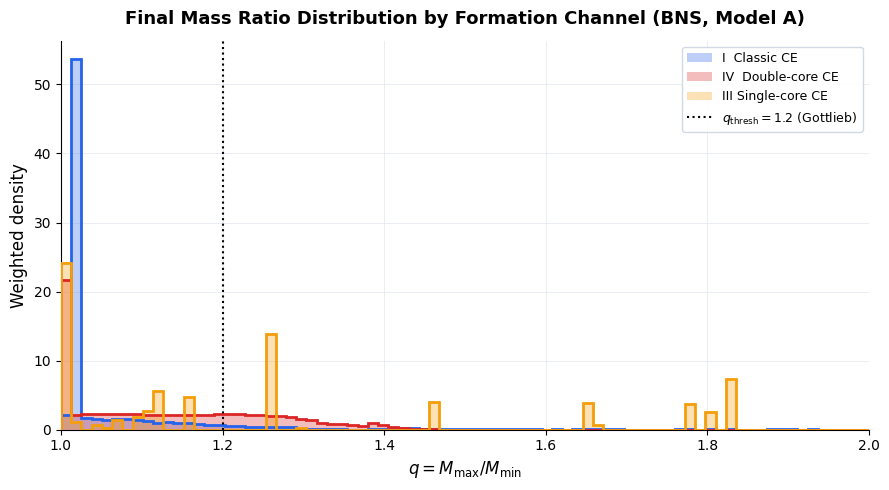

Channel                 frac(q≥1.2)
------------------------------------
I  Classic CE                 8.4%
III Single-core CE           46.1%
IV  Double-core CE           31.5%


In [37]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.set_axisbelow(True)
ax.grid(True, color='#E2E8F0', linewidth=0.5, zorder=0)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

bins_q = np.linspace(1.0, 2.0, 80)
for cname in ['I  Classic CE', 'IV  Double-core CE', 'III Single-core CE', 'II  Stable MT only']:
    cmask = channel_masks[cname]
    if cmask.sum() == 0:
        continue
    ax.hist(q[cmask], bins=bins_q, weights=w_m[cmask],
            density=True, histtype='stepfilled', lw=1.5,
            color=ch_colors_map[cname], label=cname, alpha=0.3, zorder=3)
    ax.hist(q[cmask], bins=bins_q, weights=w_m[cmask],
            density=True, histtype='step', lw=2,
            color=ch_colors_map[cname], zorder=4)

ax.axvline(1.2, color='k', ls=':', lw=1.5, zorder=5, label=r'$q_{\rm thresh} = 1.2$ (Gottlieb)')
ax.set_xlabel(r'$q = M_{\rm max} / M_{\rm min}$', fontsize=12)
ax.set_ylabel('Weighted density', fontsize=12)
ax.set_title('Final Mass Ratio Distribution by Formation Channel (BNS, Model A)',
             fontsize=13, fontweight='bold', pad=12)
ax.legend(fontsize=9, framealpha=0.9, edgecolor='#CBD5E1')
ax.set_xlim(1.0, 2.0)

plt.tight_layout()
plt.savefig('/Users/josephrodriguez/research visualization/Plots/bns_q_by_channel.png',
            dpi=200, bbox_inches='tight')
plt.show()

# ── Fraction with q >= 1.2 per channel ───────────────────────────────────────
print(f"{'Channel':<22s} {'frac(q≥1.2)':>12s}")
print('-' * 36)
for cname, cmask in channel_masks.items():
    if cmask.sum() == 0:
        continue
    frac = w_m[cmask & (q >= 1.2)].sum() / w_m[cmask].sum()
    print(f"{cname:<22s} {frac:>11.1%}")

## 8. Channel Fraction vs Metallicity

Formation channel fractions as a function of birth metallicity $Z$ (53 COMPAS grid points), compared with GRB class fractions. Does the $Z$-dependent shift in Classic-vs-Double-core-CE mirror the shift in Short-vs-Long GRB fractions?

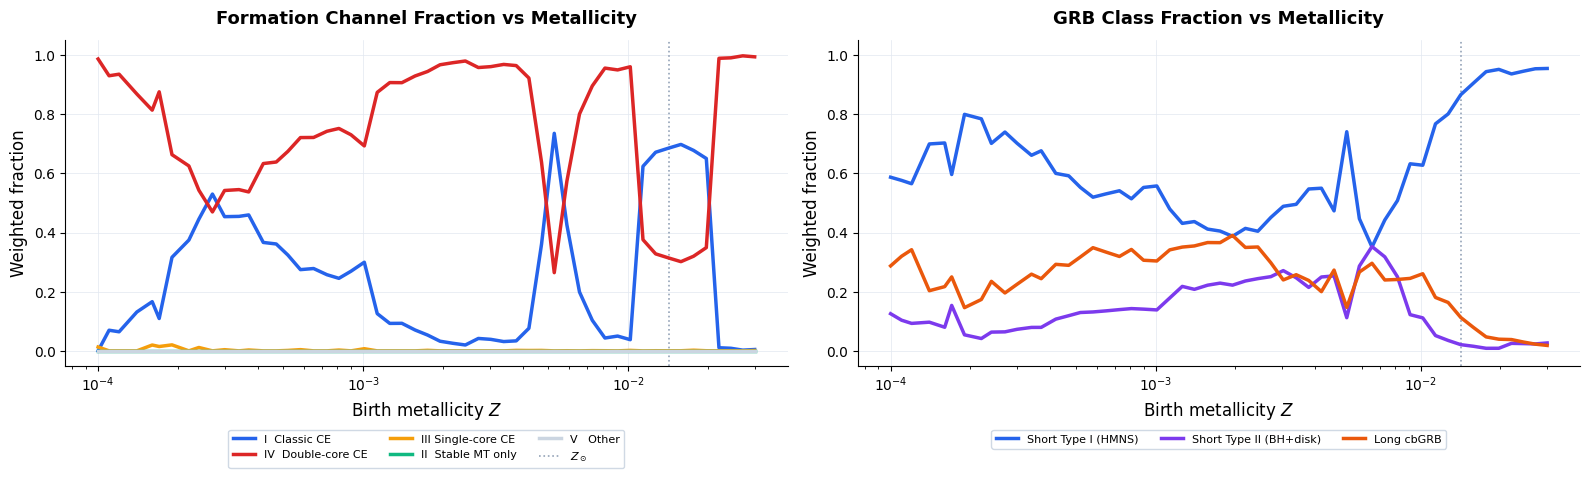

In [36]:
metallicityGrid = np.array([
    0.0001, 0.00011, 0.00012, 0.00014, 0.00016, 0.00017,
    0.00019, 0.00022, 0.00024, 0.00027, 0.0003,  0.00034,
    0.00037, 0.00042, 0.00047, 0.00052, 0.00058, 0.00065,
    0.00073, 0.00081, 0.0009,  0.00101, 0.00113, 0.00126,
    0.0014,  0.00157, 0.00175, 0.00195, 0.00218, 0.00243,
    0.00272, 0.00303, 0.00339, 0.00378, 0.00422, 0.00471,
    0.00526, 0.00587, 0.00655, 0.00732, 0.00817, 0.00912,
    0.01018, 0.01137, 0.01269, 0.01416, 0.01581, 0.01765,
    0.01971, 0.022,   0.0244,  0.02705, 0.03
])
nZ = len(metallicityGrid)

# ── Channel fractions per Z ──────────────────────────────────────────────────
ch_frac_Z = {cname: np.zeros(nZ) for cname in channel_masks}
grb_frac_Z = {'Short I': np.zeros(nZ), 'Short II': np.zeros(nZ), 'Long': np.zeros(nZ)}

for i, Zi in enumerate(metallicityGrid):
    maskZ = (Z_m == Zi)
    w_tot_Z = w_m[maskZ].sum()
    if w_tot_Z == 0:
        continue
    for cname, cmask in channel_masks.items():
        ch_frac_Z[cname][i] = w_m[maskZ & cmask].sum() / w_tot_Z
    grb_frac_Z['Short I'][i]  = w_m[maskZ & short_typeI].sum()  / w_tot_Z
    grb_frac_Z['Short II'][i] = w_m[maskZ & short_typeII].sum() / w_tot_Z
    grb_frac_Z['Long'][i]     = w_m[maskZ & long_cbGRB].sum()   / w_tot_Z

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))

for ax in axes:
    ax.set_axisbelow(True)
    ax.grid(True, color='#E2E8F0', linewidth=0.5, zorder=0)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

ax = axes[0]
for cname in ['I  Classic CE', 'IV  Double-core CE', 'III Single-core CE', 'II  Stable MT only', 'V   Other']:
    ax.plot(metallicityGrid, ch_frac_Z[cname], lw=2.5, color=ch_colors_map[cname], label=cname, zorder=3)
ax.axvline(0.0142, color='#94A3B8', ls=':', lw=1.2, zorder=2, label=r'$Z_\odot$')
ax.set_xscale('log')
ax.set_xlabel(r'Birth metallicity $Z$', fontsize=12)
ax.set_ylabel('Weighted fraction', fontsize=12)
ax.set_title('Formation Channel Fraction vs Metallicity', fontsize=13, fontweight='bold', pad=12)
ax.legend(fontsize=8, framealpha=0.9, edgecolor='#CBD5E1',
          bbox_to_anchor=(0.5, -0.18), loc='upper center', ncol=3)
ax.set_ylim(-0.05, 1.05)

ax = axes[1]
grb_colors = {'Short I': '#2563EB', 'Short II': '#7C3AED', 'Long': '#EA580C'}
grb_labels = {'Short I': 'Short Type I (HMNS)', 'Short II': 'Short Type II (BH+disk)', 'Long': 'Long cbGRB'}
for gname, vals in grb_frac_Z.items():
    ax.plot(metallicityGrid, vals, lw=2.5, color=grb_colors[gname], label=grb_labels[gname], zorder=3)
ax.axvline(0.0142, color='#94A3B8', ls=':', lw=1.2, zorder=2)
ax.set_xscale('log')
ax.set_xlabel(r'Birth metallicity $Z$', fontsize=12)
ax.set_ylabel('Weighted fraction', fontsize=12)
ax.set_title('GRB Class Fraction vs Metallicity', fontsize=13, fontweight='bold', pad=12)
ax.legend(fontsize=8, framealpha=0.9, edgecolor='#CBD5E1',
          bbox_to_anchor=(0.5, -0.18), loc='upper center', ncol=3)
ax.set_ylim(-0.05, 1.05)

plt.tight_layout(rect=[0, 0.08, 1, 1])
plt.savefig('/Users/josephrodriguez/research visualization/Plots/bns_channel_grb_fraction_vs_Z.png',
            dpi=200, bbox_inches='tight')
plt.show()

## 9. Channel-Resolved Cosmic Merger Rates

$R(z)$ broken down by formation channel $\times$ GRB class. Uses the same MSSFR setup as `GRB_CosmicRate.ipynb` (Neijssel et al. 2019).

In [31]:
sys.path.insert(0, '/Users/josephrodriguez/research visualization/COMPAS')
from compas_python_utils.cosmic_integration.FastCosmicIntegration import (
    calculate_redshift_related_params,
    find_sfr,
    find_metallicity_distribution,
)

redshifts, n_z_detect, times, time_first_SF, distances, shell_volumes = \
    calculate_redshift_related_params(max_redshift=10.0, redshift_step=0.01)
sfr     = find_sfr(redshifts)
dPdlogZ, metallicities, p_draw = find_metallicity_distribution(
    redshifts,
    min_logZ_COMPAS=np.log(0.0001),
    max_logZ_COMPAS=np.log(0.03),
)

def compute_merger_rate(redshifts, times, time_first_SF, n_formed,
                        dPdlogZ, metallicities, p_draw,
                        COMPAS_Z, COMPAS_delay_times, COMPAS_weights):
    n_z           = len(redshifts)
    redshift_step = redshifts[1] - redshifts[0]
    times_to_z    = interp1d(times, redshifts)
    Z_bins = np.clip(np.digitize(COMPAS_Z, metallicities), 0, len(metallicities) - 1)
    t_min = max(time_first_SF, times.min())
    total_merger = np.zeros(n_z)
    for i in range(len(COMPAS_delay_times)):
        form_i = n_formed * dPdlogZ[:, Z_bins[i]] / p_draw * COMPAS_weights[i]
        t_form = times - COMPAS_delay_times[i]
        valid = (t_form >= t_min)
        if not valid.any():
            continue
        j_idx      = np.where(valid)[0]
        z_form     = times_to_z(t_form[j_idx])
        z_form_idx = np.clip(np.ceil(z_form / redshift_step).astype(int), 0, n_z - 1)
        total_merger[j_idx] += form_i[z_form_idx]
    return total_merger

meanMassEvolved = 77708655
n_formed = sfr / meanMassEvolved
print(f"Cosmological grid ready: {len(redshifts)} redshift bins")

Cosmological grid ready: 1001 redshift bins


In [32]:
# ── Compute rates for each channel × GRB class ──────────────────────────────
rate_results = {}

combos = [
    ('All BNS',     np.ones(n_merging, dtype=bool)),
    ('Short cbGRB', short_cbGRB),
    ('Long cbGRB',  long_cbGRB),
]

ch_subset = [
    ('I  Classic CE',     ch_I),
    ('IV  Double-core CE', ch_IV),
]

for glabel, gmask in combos:
    rate = compute_merger_rate(
        redshifts, times, time_first_SF, n_formed, dPdlogZ, metallicities, p_draw,
        Z_m[gmask], delay_m[gmask], w_m[gmask])
    rate_results[(glabel, 'All channels')] = rate
    print(f"{glabel:20s} (all channels): z=0 {rate[0]:.1f} Gpc⁻³yr⁻¹")

for glabel, gmask in [('Short cbGRB', short_cbGRB), ('Long cbGRB', long_cbGRB)]:
    for clabel, cmask in ch_subset:
        combined = gmask & cmask
        if combined.sum() == 0:
            rate_results[(glabel, clabel)] = np.zeros(len(redshifts))
            continue
        rate = compute_merger_rate(
            redshifts, times, time_first_SF, n_formed, dPdlogZ, metallicities, p_draw,
            Z_m[combined], delay_m[combined], w_m[combined])
        rate_results[(glabel, clabel)] = rate
        print(f"{glabel:20s} × {clabel:22s}: z=0 {rate[0]:.1f} Gpc⁻³yr⁻¹")

All BNS              (all channels): z=0 1206.1 Gpc⁻³yr⁻¹
Short cbGRB          (all channels): z=0 1131.6 Gpc⁻³yr⁻¹
Long cbGRB           (all channels): z=0 74.5 Gpc⁻³yr⁻¹
Short cbGRB          × I  Classic CE         : z=0 412.4 Gpc⁻³yr⁻¹
Short cbGRB          × IV  Double-core CE    : z=0 718.9 Gpc⁻³yr⁻¹
Long cbGRB           × I  Classic CE         : z=0 26.0 Gpc⁻³yr⁻¹
Long cbGRB           × IV  Double-core CE    : z=0 48.5 Gpc⁻³yr⁻¹


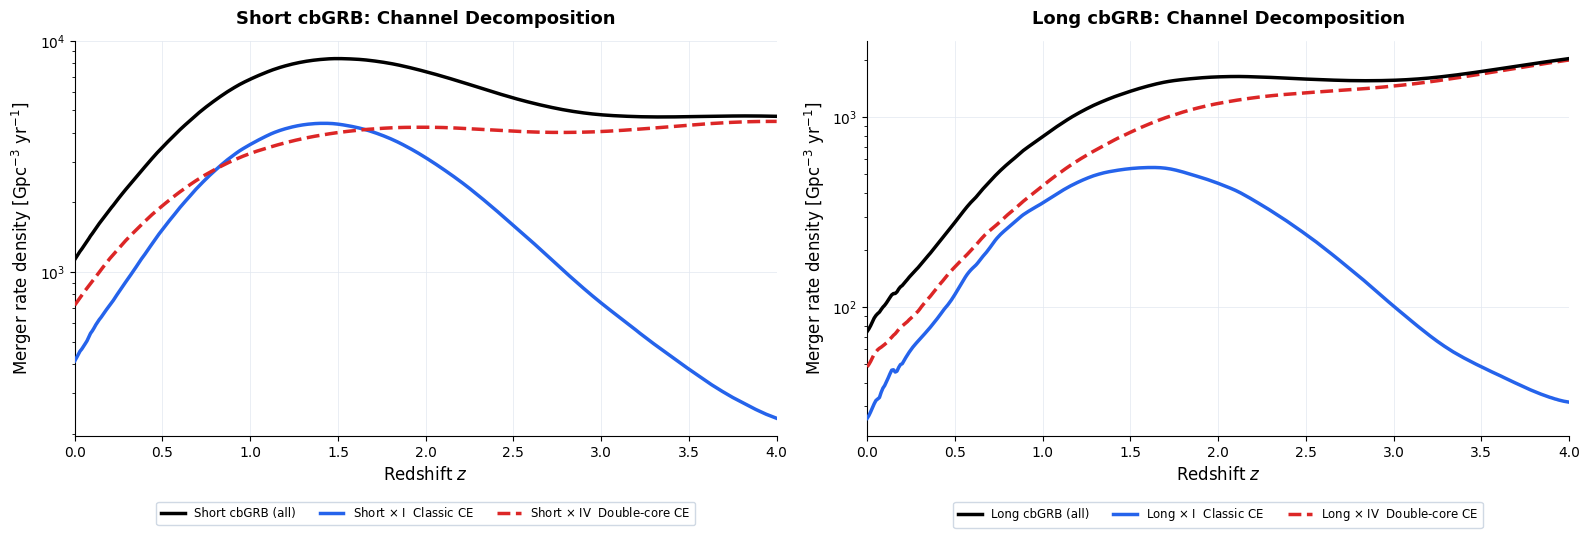

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
zmax = 4.0
zmask = redshifts <= zmax

for ax in axes:
    ax.set_axisbelow(True)
    ax.grid(True, color='#E2E8F0', linewidth=0.5, zorder=0)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# ── Left: Short cbGRB by channel ─────────────────────────────────────────────
ax = axes[0]
r_all = rate_results[('Short cbGRB', 'All channels')]
ax.plot(redshifts[zmask], r_all[zmask], 'k-', lw=2.5, label='Short cbGRB (all)', zorder=4)
for clabel, color, ls in [('I  Classic CE', '#2563EB', '-'), ('IV  Double-core CE', '#DC2626', '--')]:
    r = rate_results[('Short cbGRB', clabel)]
    ax.plot(redshifts[zmask], r[zmask], color=color, ls=ls, lw=2.5, label=f'Short $\\times$ {clabel}', zorder=3)
ax.set_yscale('log')
ax.set_xlabel('Redshift $z$', fontsize=12)
ax.set_ylabel(r'Merger rate density [Gpc$^{-3}$ yr$^{-1}$]', fontsize=12)
ax.set_title('Short cbGRB: Channel Decomposition', fontsize=13, fontweight='bold', pad=12)
ax.legend(fontsize=8.5, framealpha=0.9, edgecolor='#CBD5E1',
          bbox_to_anchor=(0.5, -0.15), loc='upper center', ncol=3)
ax.set_xlim(0, zmax)

# ── Right: Long cbGRB by channel ─────────────────────────────────────────────
ax = axes[1]
r_all = rate_results[('Long cbGRB', 'All channels')]
ax.plot(redshifts[zmask], r_all[zmask], 'k-', lw=2.5, label='Long cbGRB (all)', zorder=4)
for clabel, color, ls in [('I  Classic CE', '#2563EB', '-'), ('IV  Double-core CE', '#DC2626', '--')]:
    r = rate_results[('Long cbGRB', clabel)]
    if r.max() > 0:
        ax.plot(redshifts[zmask], r[zmask], color=color, ls=ls, lw=2.5, label=f'Long $\\times$ {clabel}', zorder=3)
ax.set_yscale('log')
ax.set_xlabel('Redshift $z$', fontsize=12)
ax.set_ylabel(r'Merger rate density [Gpc$^{-3}$ yr$^{-1}$]', fontsize=12)
ax.set_title('Long cbGRB: Channel Decomposition', fontsize=13, fontweight='bold', pad=12)
ax.legend(fontsize=8.5, framealpha=0.9, edgecolor='#CBD5E1',
          bbox_to_anchor=(0.5, -0.15), loc='upper center', ncol=3)
ax.set_xlim(0, zmax)

plt.tight_layout(rect=[0, 0.07, 1, 1])
plt.savefig('/Users/josephrodriguez/research visualization/Plots/bns_rate_by_channel_grb.png',
            dpi=200, bbox_inches='tight')
plt.show()

## 10. Summary & Discussion

### Key Results

| GRB Class | Dominant Formation Channel | Physical Reason |
|-----------|---------------------------|----------------|
| Short Type I (HMNS) | *See cross-table above* | Low $M_{\rm tot}$: lighter NS pairs from both channels |
| Short Type II (BH+disk) | *See cross-table above* | High $M_{\rm tot}$, $q < 1.2$: nearly equal masses from Double-core CE |
| Long cbGRB | *See cross-table above* | High $M_{\rm tot}$, $q \geq 1.2$: mass asymmetry from Classic CE (CCSN + USSN) |

### Physical Interpretation

The mass-ratio cut at $q = 1.2$ that separates Short Type II from Long cbGRBs may trace a physical distinction between two formation pathways, though this threshold has not been independently validated as a channel boundary (see Caveats below):

1. **Double-core CE** systems, where both stars have near-equal initial masses ($q_i \sim 0.9$-$1.0$), are stripped simultaneously in a common envelope, and undergo similar supernova mechanisms, producing nearly equal final NS masses.

2. **Classic CE** systems, where the primary is stripped by stable RLOF and undergoes a core-collapse SN (producing a potentially massive NS), while the secondary is later stripped in a CE and undergoes an ultra-stripped SN (USSN), often producing a lighter NS. This asymmetry in SN mechanisms can yield $q_{\rm final} \geq 1.2$.

### Caveats

- **Fiducial model only:** This analysis uses COMPAS Model A. The channel fractions are sensitive to CE efficiency ($\alpha$, Models F/G), mass transfer ($\beta$, Models B-D), SN kick prescriptions (Models M-O), and HG-donor CE survival (Model H). See Broekgaarden et al. ([2021](https://arxiv.org/abs/2103.02608); [2022](https://arxiv.org/abs/2112.05763)) Table 2.
- **Channel classification uncertainty:** The mapping from HDF5 flags to formation channels is approximate. The `formationChannels` group (if it provides event-sequence strings) would give a more precise classification.
- **$M_{\rm crit}$ is EOS-dependent:** The prompt collapse threshold depends on the neutron star equation of state ($R_{1.4}$). The `rate_bns_mcrit_sensitivity.png` plot shows a 3-5x variation in the Long cbGRB rate at low redshift for $M_{\rm crit} \in [2.6, 3.0]\,M_\odot$.
- **Single metallicity-specific SFR model:** Only the Neijssel et al. (2019) MSSFR is used here. Broekgaarden et al. (2022) showed that $\mathcal{S}(Z,z)$ variations significantly impact NSNS rate and mass distribution shapes.
- **$q = 1.2$ as a channel diagnostic:** No publication has validated $q = 1.2$ as a formation channel boundary. The NS mass function is intrinsically narrow (~1.1-1.6 $M_\odot$), and Tauris et al. (2017, ApJ 846, 170) find only a ~0.1 $M_\odot$ systematic difference between recycled (CCSN) and non-recycled (USSN) NS masses. The most asymmetric known merging DNS, PSR J1913+1102, has $q \approx 0.78$ (Ferdman et al. 2020, Nature 583, 211). The cross-tabulation in Section 5 directly tests whether this threshold has any channel-discriminating power.
- **Isolated binary evolution only.** No dynamical formation channels (globular clusters, nuclear star clusters, AGN disks) are considered. Dynamical BNS mergers may have distinct mass-ratio distributions.
- **Rapid population synthesis.** COMPAS uses analytic fitting formulae (Hurley et al. 2000), not detailed stellar evolution, introducing systematic uncertainties in radii, core masses, and envelope binding energies.
- **Wolf-Rayet wind mass loss.** Explored in Broekgaarden et al. (2022) models S and T ($f_{\rm WR} = 0.1, 5$) but not tested here. WR wind prescriptions directly affect pre-SN helium star masses and therefore final NS masses and mass ratios.

### Future Directions

- **Multi-model extension:** Run this analysis across the Broekgaarden et al. (2022) 560-model grid to test whether the formation-channel to GRB-class mapping is robust or model-dependent.
- **Explicit channel labels:** Use the `formationChannels` HDF5 group (if it contains event-sequence strings per Vigna-Gómez et al. 2018) for a definitive classification.
- **Connection to BH-NS:** Compare with the BHNS formation channel analysis in Broekgaarden et al. ([2021, Paper I](https://arxiv.org/abs/2103.02608); see also [2022, Paper II](https://arxiv.org/abs/2112.05763) for all DCOs), which shows the Classic CE channel dominates for BHNS (~86%) but Double-core CE is negligible (~1%). This is the reverse of what we expect for BNS.